In [9]:
from google.colab import drive
import os

# Kết nối Google Drive
drive.mount('/content/drive')

# Thay 'Ten_Thu_Muc_Shortcut' bằng tên thư mục bạn vừa tạo lối tắt trên Drive
DATASET_DIR = "/content/drive/MyDrive/DIP"

print("Các tệp/thư mục có trong Drive:")
print(os.listdir(DATASET_DIR))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Các tệp/thư mục có trong Drive:
['data']


In [10]:
# 1. Clone repository comic-text-detector
!git clone https://github.com/Ajatt-Tools/comic_text_detector.git
%cd comic_text_detector

# 2. Cài đặt các thư viện yêu cầu
!pip install -r requirements.txt
!pip install opencv-python pillow numpy torch torchvision pandas

# 3. Tải checkpoint chính thức (79.9MB)
!mkdir -p data/models
!wget -O data/models/comictextdetector.pt https://github.com/zyddnys/manga-image-translator/releases/download/beta-0.2.1/comictextdetector.pt

Cloning into 'comic_text_detector'...
remote: Enumerating objects: 388, done.
remote: Counting objects: 100% (124/124), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 388 (delta 105), reused 91 (delta 91), pack-reused 264 (from 1)
Receiving objects: 100% (388/388), 10.06 MiB | 17.39 MiB/s, done.
Resolving deltas: 100% (257/257), done.
/content/comic_text_detector/comic_text_detector
--2026-09-12 13:36:38--  https://github.com/zyddnys/manga-image-translator/releases/download/beta-0.2.1/comictextdetector.pt
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/339920287/1a1c3ae6-bc1f-47bf-82b1-f2df3dd64652?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-09-12T14%3A22%3A24Z&rscd=attachment%3B+filename%3Dcomictextdetector.pt&rsct=application%2Foctet-stream&skoid=96c2d410

In [11]:
import os
import time
import json
import torch
import cv2
import numpy as np
import subprocess
from comic_text_detector.inference import TextDetector

model_path = "data/models/comictextdetector.pt"
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Availability Check theo FR-016 & FR-018
assert os.path.exists(model_path), f"Không tìm thấy model tại {model_path}"
assert os.path.getsize(model_path) > 70 * 1024 * 1024, "File weight bị tải lỗi hoặc thiếu dung lượng!"

detector = TextDetector(model_path=model_path, input_size=1024, device=device)
print(f"[*] Khởi tạo thành công model trên thiết bị: {device}")

# Lấy commit hash chính xác từ repo
try:
    commit_hash = subprocess.check_output(["git", "rev-parse", "HEAD"], cwd="/content/comic_text_detector").decode("utf-8").strip()
except Exception:
    commit_hash = "master"
print(f"[*] Repository Commit: {commit_hash}")

# Kích thước aligned space chuẩn bắt buộc theo Spec 1 & Onboarding
TARGET_WIDTH = 1654
TARGET_HEIGHT = 1170

def infer_single_page(image_path, manga_name, page_id):
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError(f"Không thể đọc ảnh: {image_path}")
    h_orig, w_orig = image.shape[:2]

    t0 = time.time()
    # Suy luận (chỉ lấy pixel mask, bỏ qua text lines/boxes)
    ret = detector(image, refine_mode=1, keep_undetected_mask=True)
    if isinstance(ret, (tuple, list)):
        mask = ret[0]
    else:
        mask = ret
    infer_time = time.time() - t0

    # Chuẩn hóa về binary uint8: background = 0, text = 255 theo Spec 1
    if mask.dtype != np.uint8:
        binary_mask = (mask > 0.5).astype(np.uint8) * 255
    else:
        _, binary_mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)

    # Đảm bảo đúng không gian Aligned Space (1654 x 1170) theo Spec 1
    if binary_mask.shape[1] != TARGET_WIDTH or binary_mask.shape[0] != TARGET_HEIGHT:
        binary_mask = cv2.resize(binary_mask, (TARGET_WIDTH, TARGET_HEIGHT), interpolation=cv2.INTER_NEAREST)

    # Metadata sidecar đúng 100% schema Mục 6 ONBOARDING.md
    metadata = {
        "image_id": f"{manga_name}/{page_id}",
        "method": "comic-text-detector",
        "repository": "https://github.com/Ajatt-Tools/comic_text_detector",
        "commit": commit_hash,
        "checkpoint": "comictextdetector.pt",
        "input_size": [w_orig, h_orig],
        "output_size": [TARGET_WIDTH, TARGET_HEIGHT],
        "preprocessing": ["letterbox_1024x1024_stride64", "scale_1_div_255"],
        "postprocessing": ["sigmoid_threshold_0.235", "unpad_and_crop", "resize_nearest_to_aligned_space"],
        "threshold": 0.235,
        "alignment": "spec-001-aligned-space",
        "device": device,
        "inference_time_seconds": round(infer_time, 4),
        "status": "success",
        "error": None
    }
    return binary_mask, metadata

[*] Khởi tạo thành công model trên thiết bị: cuda
[*] Repository Commit: e958d8b4a7461528e8df8aa8156e3928b57b2fc6


In [12]:
import os

print("[*] Đang giải nén ảnh gốc vào /content/data/raw...")
os.makedirs("/content/data/raw", exist_ok=True)
!unzip -q "/content/drive/MyDrive/DIP/data/raw/Manga109s_released_2026_05_21.zip" -d /content/data/raw/

print("[*] Đang giải nén ground-truth vào /content/data/groundtruth...")
os.makedirs("/content/data/groundtruth", exist_ok=True)
!unzip -q "/content/drive/MyDrive/DIP/data/groundtruth/post-processed.zip" -d /content/data/groundtruth/

print("✅ Đã giải nén xong!")

[*] Đang giải nén ảnh gốc vào /content/data/raw...
replace /content/data/raw/Manga109s_released_2026_05_21/books.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
[*] Đang giải nén ground-truth vào /content/data/groundtruth...
replace /content/data/groundtruth/post-processed/AisazuNihaIrarenai/000.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
✅ Đã giải nén xong!


In [14]:
import os
import json
import cv2

# Đường dẫn sau khi đã giải nén
RAW_IMAGES_ROOT = "/content/data/raw/Manga109s_released_2026_05_21/images"
# Dự phòng nếu cấu trúc giải nén không có lớp Manga109s...
if not os.path.exists(RAW_IMAGES_ROOT):
    RAW_IMAGES_ROOT = "/content/data/raw/images" if os.path.exists("/content/data/raw/images") else "/content/data/raw"

GT_ROOT = "/content/data/groundtruth/post-processed"
if not os.path.exists(GT_ROOT):
    GT_ROOT = "/content/data/groundtruth"

OUTPUT_DIR = "/content/deliverables/comic-text-detector"
os.makedirs(f"{OUTPUT_DIR}/masks", exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/metadata", exist_ok=True)

# 1. Quét tìm các cặp (manga, page_id) hợp lệ theo đúng Spec 1
pages_to_run = []
orphan_count = 0

print(f"[*] Quét dữ liệu từ GT: {GT_ROOT}")
print(f"[*] Đối chiếu ảnh gốc tại: {RAW_IMAGES_ROOT}")

for manga_name in sorted(os.listdir(GT_ROOT)):
    manga_gt_dir = os.path.join(GT_ROOT, manga_name)
    if os.path.isdir(manga_gt_dir):
        for mask_file in sorted(os.listdir(manga_gt_dir)):
            if mask_file.lower().endswith(".png"):
                page_id = os.path.splitext(mask_file)[0]

                # Tìm file ảnh gốc tương ứng (.jpg)
                img_path = os.path.join(RAW_IMAGES_ROOT, manga_name, f"{page_id}.jpg")
                if not os.path.exists(img_path):
                    # Thử định dạng .png nếu có
                    img_path = os.path.join(RAW_IMAGES_ROOT, manga_name, f"{page_id}.png")

                if os.path.exists(img_path):
                    pages_to_run.append((manga_name, page_id, img_path))
                else:
                    orphan_count += 1

print(f"-> Tìm thấy {len(pages_to_run)} trang hợp lệ có đủ ảnh và mask (Dự kiến: 390).")
print(f"-> Số mask không có ảnh gốc (orphan): {orphan_count} (Dự kiến: 60).")

# 2. Chạy suy luận Benchmark
errors = []

for idx, (manga, page_id, img_path) in enumerate(pages_to_run):
    save_mask_dir = f"{OUTPUT_DIR}/masks/{manga}"
    save_meta_dir = f"{OUTPUT_DIR}/metadata/{manga}"
    os.makedirs(save_mask_dir, exist_ok=True)
    os.makedirs(save_meta_dir, exist_ok=True)

    try:
        mask, meta = infer_single_page(img_path, manga, page_id)

        # Lưu binary mask PNG {0, 255} kích thước 1654x1170
        cv2.imwrite(f"{save_mask_dir}/{page_id}.png", mask)

        # Lưu file sidecar metadata JSON
        with open(f"{save_meta_dir}/{page_id}.json", "w", encoding="utf-8") as f:
            json.dump(meta, f, indent=2)

    except Exception as e:
        err_msg = str(e)
        errors.append({"image_id": f"{manga}/{page_id}", "error": err_msg})
        print(f"[!] Lỗi tại {manga}/{page_id}: {err_msg}")

    # In log tiến độ mỗi 50 trang
    if (idx + 1) % 50 == 0 or (idx + 1) == len(pages_to_run):
        print(f"Tiến độ: {idx + 1}/{len(pages_to_run)} trang.")

# 3. Lưu file errors.json
with open(f"{OUTPUT_DIR}/errors.json", "w", encoding="utf-8") as f:
    json.dump(errors, f, indent=2)

print("✅ Hoàn tất toàn bộ benchmark!")

[*] Quét dữ liệu từ GT: /content/data/groundtruth/post-processed
[*] Đối chiếu ảnh gốc tại: /content/data/raw/Manga109s_released_2026_05_21/images
-> Tìm thấy 390 trang hợp lệ có đủ ảnh và mask (Dự kiến: 390).
-> Số mask không có ảnh gốc (orphan): 60 (Dự kiến: 60).
Tiến độ: 50/390 trang.
Tiến độ: 100/390 trang.
Tiến độ: 150/390 trang.
Tiến độ: 200/390 trang.
Tiến độ: 250/390 trang.
Tiến độ: 300/390 trang.
Tiến độ: 350/390 trang.
Tiến độ: 390/390 trang.
✅ Hoàn tất toàn bộ benchmark!


In [15]:
import pandas as pd
import os
import cv2
import numpy as np
import json

print("[*] Đang tính toán định lượng IoU, Precision, Recall, F1 trên toàn bộ 390 trang...")

metrics_list = []

for idx, (manga, page_id, img_path) in enumerate(pages_to_run):
    pred_path = f"{OUTPUT_DIR}/masks/{manga}/{page_id}.png"
    gt_path = f"{GT_ROOT}/{manga}/{page_id}.png"
    meta_path = f"{OUTPUT_DIR}/metadata/{manga}/{page_id}.json"

    if not (os.path.exists(pred_path) and os.path.exists(gt_path)):
        continue

    pred_mask = cv2.imread(pred_path, cv2.IMREAD_GRAYSCALE)
    gt_raw = cv2.imread(gt_path)

    # Căn chỉnh ground-truth mask chuẩn Spec 1 (lossless crop góc trên-trái về 1654x1170)
    gt_cropped = gt_raw[:TARGET_HEIGHT, :TARGET_WIDTH]
    gt_binary = np.where(np.all(gt_cropped == [255, 255, 255], axis=-1), 0, 255).astype(np.uint8)

    # Tính toán pixel-level metrics
    pred_text = (pred_mask == 255)
    gt_text = (gt_binary == 255)

    tp = np.logical_and(pred_text, gt_text).sum()
    fp = np.logical_and(pred_text, ~gt_text).sum()
    fn = np.logical_and(~pred_text, gt_text).sum()

    intersection = tp
    union = tp + fp + fn

    iou = float(intersection / union) if union > 0 else (1.0 if not pred_text.any() and not gt_text.any() else 0.0)
    precision = float(tp / (tp + fp)) if (tp + fp) > 0 else 0.0
    recall = float(tp / (tp + fn)) if (tp + fn) > 0 else 0.0
    f1 = float(2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    # Đọc lại và chuẩn hóa metadata JSON nếu cần
    infer_time = 0.0
    if os.path.exists(meta_path):
        with open(meta_path, "r", encoding="utf-8") as f:
            meta_dict = json.load(f)
            infer_time = meta_dict.get("inference_time_seconds", 0.0)

            # Đảm bảo metadata chứa đầy đủ các trường yêu cầu
            meta_dict["commit"] = commit_hash
            meta_dict["preprocessing"] = ["letterbox_1024x1024_stride64", "scale_1_div_255"]
            meta_dict["postprocessing"] = ["sigmoid_threshold_0.235", "unpad_and_crop", "resize_nearest_to_aligned_space"]
            meta_dict["alignment"] = "spec-001-aligned-space"
            with open(meta_path, "w", encoding="utf-8") as fw:
                json.dump(meta_dict, fw, indent=2)

    metrics_list.append({
        "image_id": f"{manga}/{page_id}",
        "manga": manga,
        "page_id": page_id,
        "iou": round(iou, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "inference_time_seconds": infer_time
    })

# Xuất metrics_per_page.csv theo Mục 9 ONBOARDING.md
df_metrics = pd.DataFrame(metrics_list)
csv_path = f"{OUTPUT_DIR}/metrics_per_page.csv"
df_metrics.to_csv(csv_path, index=False)
print(f"✅ Đã lưu file: {csv_path}")

# Xuất metrics_summary.json theo Mục 9 ONBOARDING.md
summary_dict = {
    "method": "comic-text-detector",
    "total_valid_pages": len(df_metrics),
    "successful_pages": len(df_metrics),
    "failed_pages": 0,
    "metrics_mean": {
        "iou": round(float(df_metrics["iou"].mean()), 4),
        "precision": round(float(df_metrics["precision"].mean()), 4),
        "recall": round(float(df_metrics["recall"].mean()), 4),
        "f1": round(float(df_metrics["f1"].mean()), 4)
    },
    "metrics_std": {
        "iou": round(float(df_metrics["iou"].std()), 4),
        "precision": round(float(df_metrics["precision"].std()), 4),
        "recall": round(float(df_metrics["recall"].std()), 4),
        "f1": round(float(df_metrics["f1"].std()), 4)
    },
    "average_inference_time_seconds": round(float(df_metrics["inference_time_seconds"].mean()), 4),
    "total_inference_time_seconds": round(float(df_metrics["inference_time_seconds"].sum()), 2),
    "device": device
}

summary_json_path = f"{OUTPUT_DIR}/metrics_summary.json"
with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(summary_dict, f, indent=2)
print(f"✅ Đã lưu file: {summary_json_path}")

print(f"\n--- KẾT QUẢ BENCHMARK COMIC-TEXT-DETECTOR (N={len(df_metrics)}) ---")
print(f"Mean IoU:       {summary_dict['metrics_mean']['iou']} ± {summary_dict['metrics_std']['iou']}")
print(f"Mean F1-score:  {summary_dict['metrics_mean']['f1']} ± {summary_dict['metrics_std']['f1']}")
print(f"Mean Precision: {summary_dict['metrics_mean']['precision']}")
print(f"Mean Recall:    {summary_dict['metrics_mean']['recall']}")
print(f"Inference TB:   {summary_dict['average_inference_time_seconds']}s/trang ({device})")

[*] Đang tính toán định lượng IoU, Precision, Recall, F1 trên toàn bộ 390 trang...
✅ Đã lưu file: /content/deliverables/comic-text-detector/metrics_per_page.csv
✅ Đã lưu file: /content/deliverables/comic-text-detector/metrics_summary.json

--- KẾT QUẢ BENCHMARK COMIC-TEXT-DETECTOR (N=390) ---
Mean IoU:       0.142 ± 0.1255
Mean F1-score:  0.2297 ± 0.1752
Mean Precision: 0.3372
Mean Recall:    0.1896
Inference TB:   0.3813s/trang (cuda)


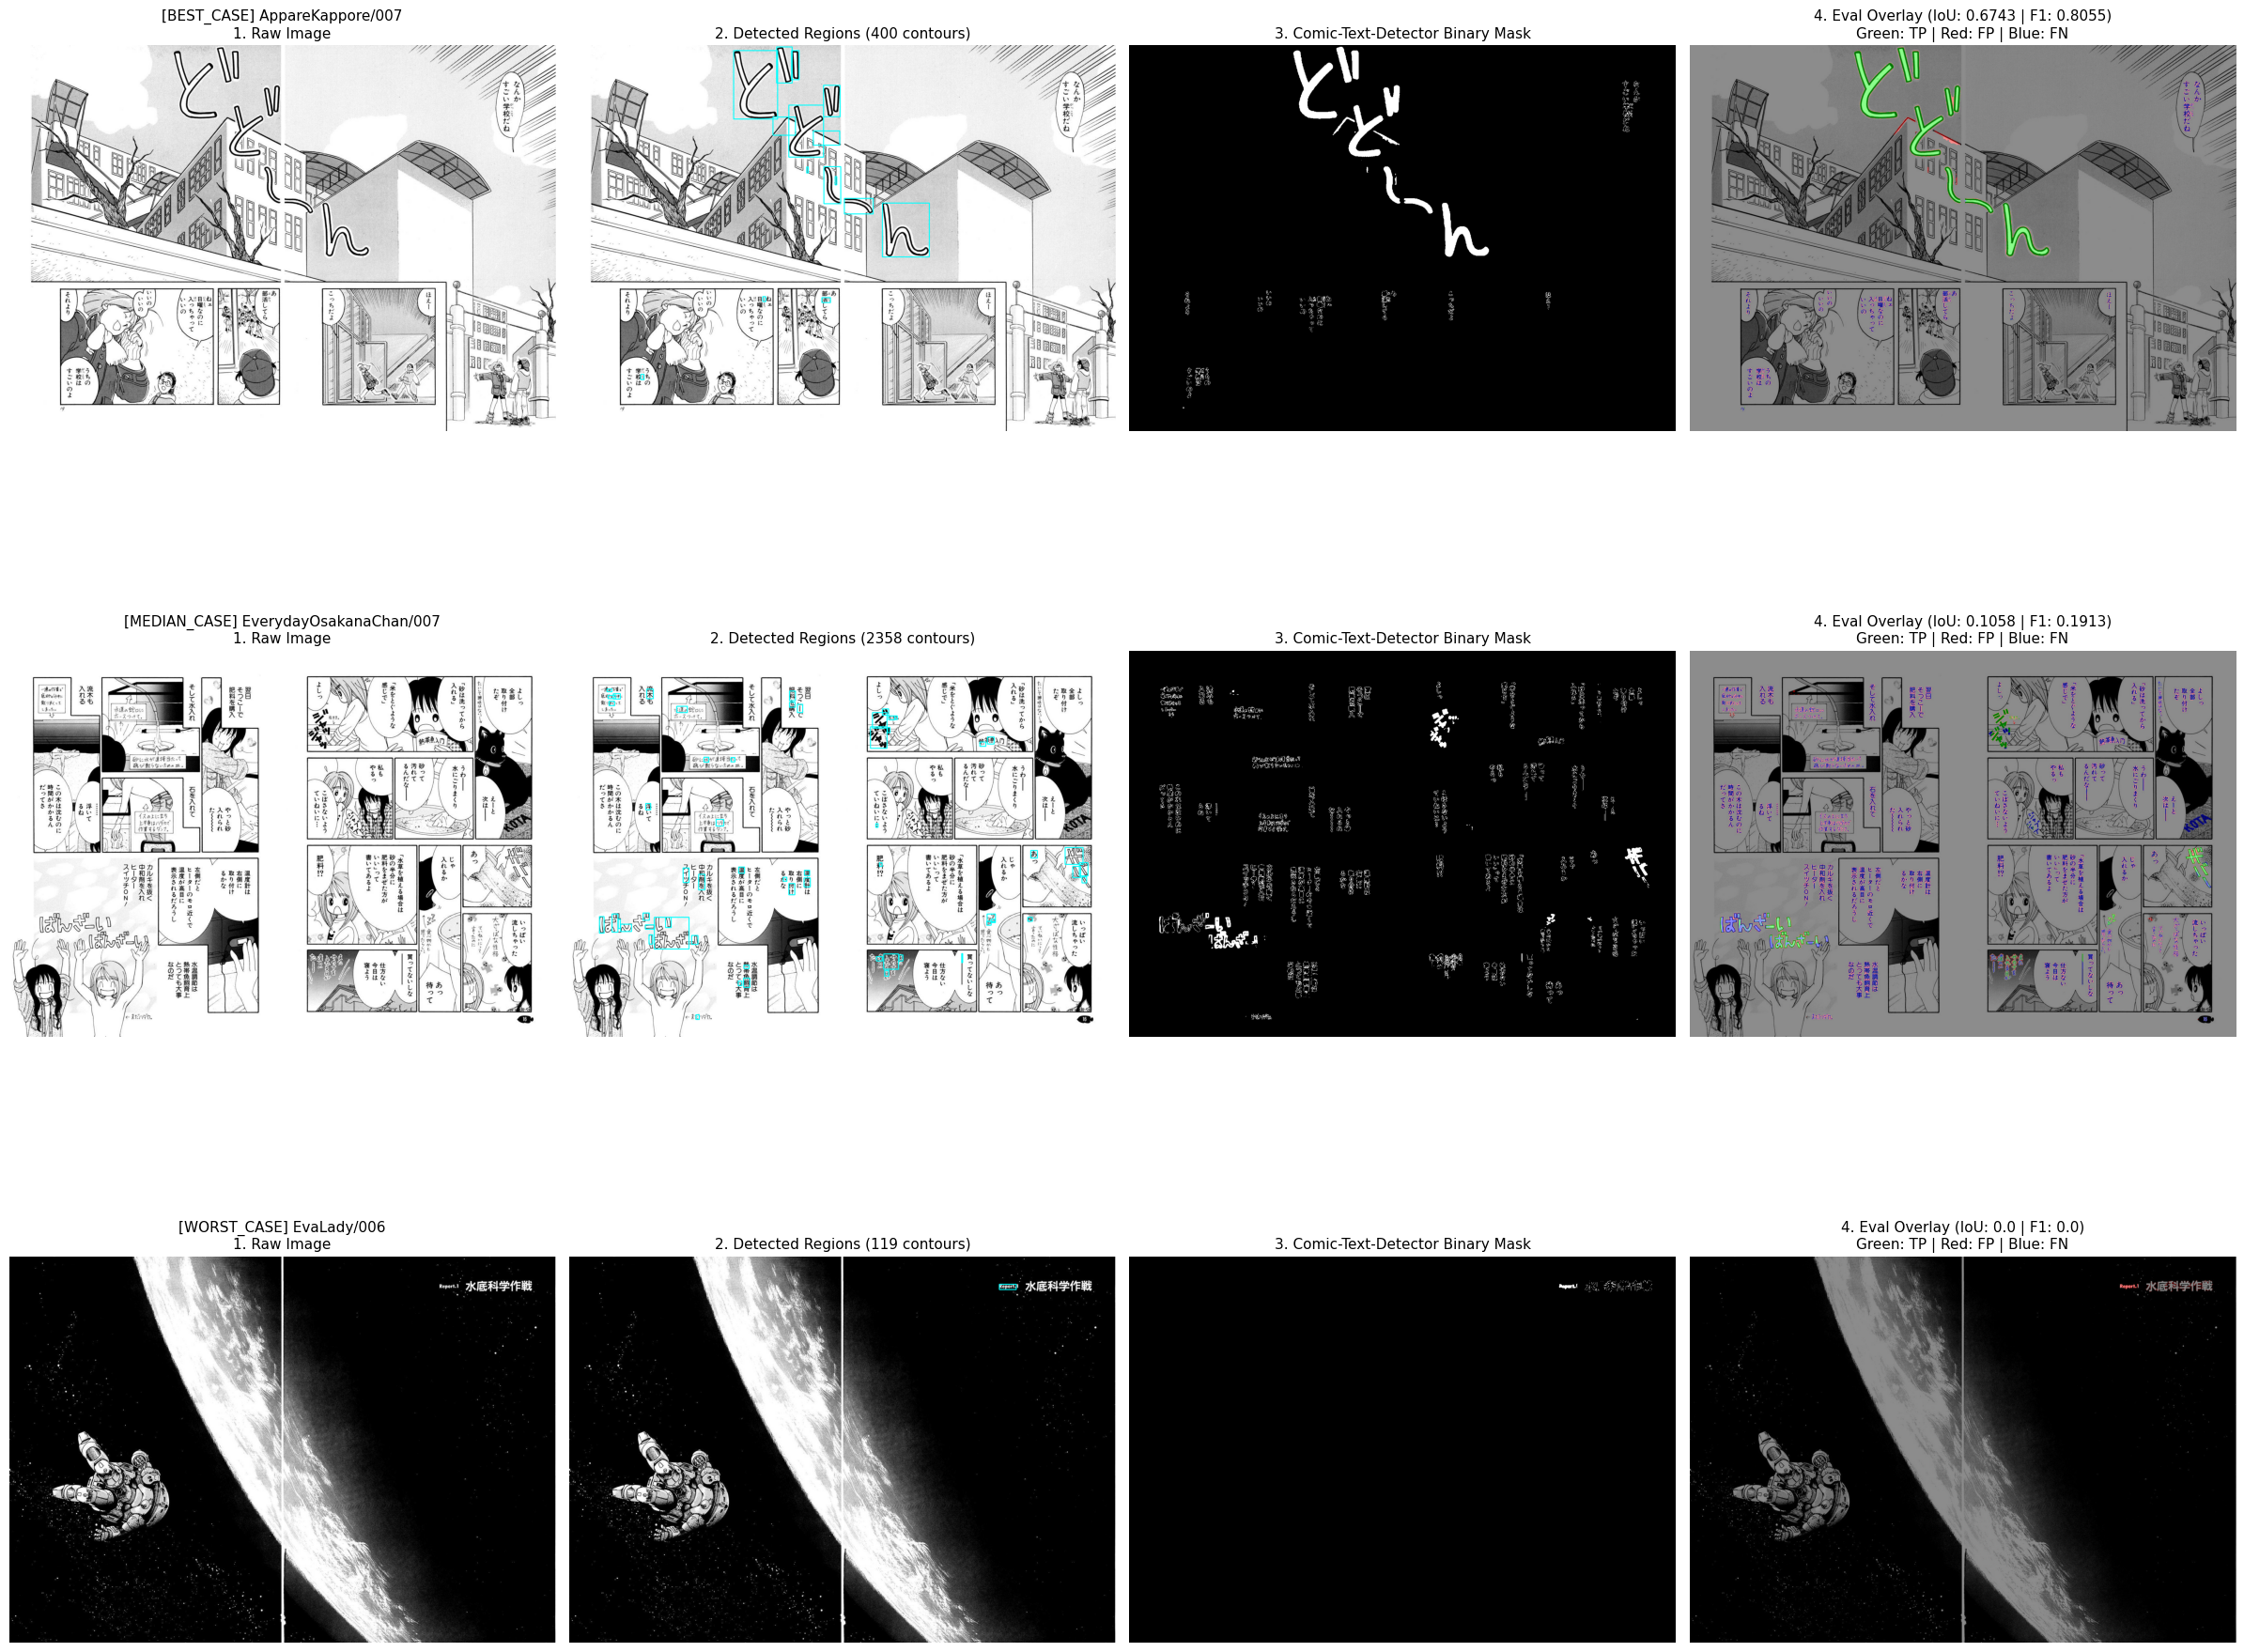

✅ Đã lưu ảnh phân tích ca tiêu biểu tại: /content/deliverables/comic-text-detector/visualizations/representative_cases.png


In [16]:
# Sắp xếp F1-score để tìm 3 ca đại diện
df_sorted = df_metrics.sort_values(by="f1", ascending=False).reset_index(drop=True)

cases = [
    {"label": "BEST_CASE", "row": df_sorted.iloc[0]},
    {"label": "MEDIAN_CASE", "row": df_sorted.iloc[len(df_sorted) // 2]},
    {"label": "WORST_CASE", "row": df_sorted.iloc[-1]}
]

import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 4, figsize=(24, 21))

for row_idx, item in enumerate(cases):
    case_label = item["label"]
    manga = item["row"]["manga"]
    page = item["row"]["page_id"]
    iou_val = item["row"]["iou"]
    f1_val = item["row"]["f1"]

    raw_img = cv2.imread(f"{RAW_IMAGES_ROOT}/{manga}/{page}.jpg")
    pred_mask = cv2.imread(f"{OUTPUT_DIR}/masks/{manga}/{page}.png", cv2.IMREAD_GRAYSCALE)
    gt_raw = cv2.imread(f"{GT_ROOT}/{manga}/{page}.png")
    gt_cropped = gt_raw[:TARGET_HEIGHT, :TARGET_WIDTH]
    gt_binary = np.where(np.all(gt_cropped == [255, 255, 255], axis=-1), 0, 255).astype(np.uint8)

    # 1. Bounding contours
    contours, _ = cv2.findContours(pred_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boxes_img = raw_img.copy()
    for cnt in contours:
        if cv2.contourArea(cnt) > 40:
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(boxes_img, (x, y), (x + w, y + h), (255, 255, 0), 2)

    # 2. Overlay so khớp màu sắc
    comp_map = np.zeros_like(raw_img)
    comp_map[(pred_mask == 255) & (gt_binary == 255)] = [0, 255, 0] # True Positive: Xanh lá
    comp_map[(pred_mask == 255) & (gt_binary == 0)] = [0, 0, 255]   # False Positive: Đỏ
    comp_map[(pred_mask == 0) & (gt_binary == 255)] = [255, 0, 0]   # False Negative: Xanh dương
    diff_overlay = cv2.addWeighted(raw_img, 0.55, comp_map, 0.45, 0)

    # Render các panel
    axes[row_idx, 0].imshow(cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB))
    axes[row_idx, 0].set_title(f"[{case_label}] {manga}/{page}\n1. Raw Image", fontsize=11)
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].imshow(cv2.cvtColor(boxes_img, cv2.COLOR_BGR2RGB))
    axes[row_idx, 1].set_title(f"2. Detected Regions ({len(contours)} contours)", fontsize=11)
    axes[row_idx, 1].axis('off')

    axes[row_idx, 2].imshow(pred_mask, cmap='gray')
    axes[row_idx, 2].set_title("3. Comic-Text-Detector Binary Mask", fontsize=11)
    axes[row_idx, 2].axis('off')

    axes[row_idx, 3].imshow(cv2.cvtColor(diff_overlay, cv2.COLOR_BGR2RGB))
    axes[row_idx, 3].set_title(f"4. Eval Overlay (IoU: {iou_val} | F1: {f1_val})\nGreen: TP | Red: FP | Blue: FN", fontsize=11)
    axes[row_idx, 3].axis('off')

    # Lưu file từng trang đại diện
    save_vis_sub = f"{OUTPUT_DIR}/visualizations/{manga}"
    os.makedirs(save_vis_sub, exist_ok=True)
    single_fig, single_ax = plt.subplots(1, 4, figsize=(24, 7))
    single_ax[0].imshow(cv2.cvtColor(raw_img, cv2.COLOR_BGR2RGB)); single_ax[0].axis('off'); single_ax[0].set_title("Raw Image")
    single_ax[1].imshow(cv2.cvtColor(boxes_img, cv2.COLOR_BGR2RGB)); single_ax[1].axis('off'); single_ax[1].set_title("Detected Regions")
    single_ax[2].imshow(pred_mask, cmap='gray'); single_ax[2].axis('off'); single_ax[2].set_title("Prediction Mask")
    single_ax[3].imshow(cv2.cvtColor(diff_overlay, cv2.COLOR_BGR2RGB)); single_ax[3].axis('off'); single_ax[3].set_title(f"Eval (F1: {f1_val})")
    single_fig.tight_layout()
    single_fig.savefig(f"{save_vis_sub}/{page}_{case_label.lower()}.png", dpi=150, bbox_inches='tight')
    plt.close(single_fig)

plt.tight_layout()
plt.show()

# Lưu ảnh tổng hợp đại diện
summary_vis_img = f"{OUTPUT_DIR}/visualizations/representative_cases.png"
os.makedirs(os.path.dirname(summary_vis_img), exist_ok=True)
fig.savefig(summary_vis_img, dpi=200, bbox_inches='tight')
print(f"✅ Đã lưu ảnh phân tích ca tiêu biểu tại: {summary_vis_img}")

In [17]:
import shutil

# 1. Xuất file requirements.txt
!pip freeze > {OUTPUT_DIR}/requirements.txt
print(f"✅ Đã tạo file: {OUTPUT_DIR}/requirements.txt")

# 2. Xuất file README.md cho gói bàn giao
readme_text = f"""# Deliverables: comic-text-detector

- **Thành viên phụ trách:** Ha Duy Anh (Member 02)
- **Phương pháp:** comic-text-detector (YOLOv5 + DBNet + U-Net)
- **Repository:** https://github.com/Ajatt-Tools/comic_text_detector
- **Commit:** {commit_hash}
- **Checkpoint Source:** https://github.com/zyddnys/manga-image-translator/releases/download/beta-0.2.1/comictextdetector.pt
- **License:** GPL-3.0
- **Aligned Space:** 1654 x 1170 (Width x Height)
- **Số trang đánh giá thành công:** {summary_dict['successful_pages']}/{summary_dict['total_valid_pages']} trang
- **Inference Hardware:** {device.upper()}

## Kết quả định lượng tổng kết
- **Mean IoU:** {summary_dict['metrics_mean']['iou']} ± {summary_dict['metrics_std']['iou']}
- **Mean F1-score:** {summary_dict['metrics_mean']['f1']} ± {summary_dict['metrics_std']['f1']}
- **Mean Precision:** {summary_dict['metrics_mean']['precision']} ± {summary_dict['metrics_std']['precision']}
- **Mean Recall:** {summary_dict['metrics_mean']['recall']} ± {summary_dict['metrics_std']['recall']}
- **Thời gian suy luận trung bình:** {summary_dict['average_inference_time_seconds']} giây/trang
"""

with open(f"{OUTPUT_DIR}/README.md", "w", encoding="utf-8") as f:
    f.write(readme_text)
print(f"✅ Đã tạo file: {OUTPUT_DIR}/README.md")

# 3. Nén toàn bộ thư mục deliverables thành file ZIP
zip_target = "/content/comic_text_detector_deliverables"
shutil.make_archive(zip_target, 'zip', OUTPUT_DIR)
print(f"✅ Đã nén thành công toàn bộ thư mục bàn giao: {zip_target}.zip")

# 4. Tự động lưu bản sao file zip vào Google Drive cá nhân
drive_dest = "/content/drive/MyDrive/Drive/comic_text_detector_deliverables.zip"
shutil.copyfile(f"{zip_target}.zip", drive_dest)
print(f"✅ Đã lưu file zip an toàn trên Drive tại: {drive_dest}")

✅ Đã tạo file: /content/deliverables/comic-text-detector/requirements.txt
✅ Đã tạo file: /content/deliverables/comic-text-detector/README.md
✅ Đã nén thành công toàn bộ thư mục bàn giao: /content/comic_text_detector_deliverables.zip
✅ Đã lưu file zip an toàn trên Drive tại: /content/drive/MyDrive/Drive/comic_text_detector_deliverables.zip


In [18]:
# Push lên drive
import os
import shutil

# Thư mục đích trên Google Drive
drive_target_dir = "/content/drive/MyDrive/DIP/comic_text_dectector_Ha-Duy-Anh"
os.makedirs(drive_target_dir, exist_ok=True)

# 1. Copy thư mục deliverables (kết quả nộp bài)
if os.path.exists("/content/deliverables"):
    print("[*] Đang đẩy thư mục deliverables lên Drive...")
    shutil.copytree("/content/deliverables", os.path.join(drive_target_dir, "deliverables"), dirs_exist_ok=True)

# 2. Copy file zip deliverables
if os.path.exists("/content/comic_text_detector_deliverables.zip"):
    print("[*] Đang copy file zip deliverables...")
    shutil.copyfile("/content/comic_text_detector_deliverables.zip", os.path.join(drive_target_dir, "comic_text_detector_deliverables.zip"))

# 3. Copy thư mục models
if os.path.exists("/content/comic_text_detector"):
    print("[*] Đang copy thư mục models...")
    shutil.copytree("/content/comic_text_detector", os.path.join(drive_target_dir, "comic_text_detector"), dirs_exist_ok=True)

print("✅ Đã hoàn tất đưa các thư mục làm việc lên Drive tại:", drive_target_dir)
print("Nội dung đã lưu trên Drive:")
print(os.listdir(drive_target_dir))

[*] Đang đẩy thư mục deliverables lên Drive...
[*] Đang copy file zip deliverables...
[*] Đang copy thư mục models...
✅ Đã hoàn tất đưa các thư mục làm việc lên Drive tại: /content/drive/MyDrive/DIP/comic_text_dectector_Ha-Duy-Anh
Nội dung đã lưu trên Drive:
['deliverables', 'comic_text_detector_deliverables.zip', 'comic_text_detector']
